<div style="text-align: center; margin-bottom: 20px;">
    <img src="src/img/logo.png" alt="Trazos y Hojas" width="500"/>
</div>

<h1 style="color:#3E5F36; border-bottom: 3px solid #8FAD6D; padding-bottom: 6px;"> EDA — Trazos y Hojas</h1>

> **Gestión Inteligente de Compras:** Análisis de Costos, Márgenes y Valor en el Inventario de Artículos

**Periodo:** 1 de enero – 8 de mayo de 2026  
**Datasets utilizados:** `agrupacion_horas.csv` · `cierre_caja.csv` · `compras_articulos.csv` · `compras_tpv.csv` · `ventas_glovo.csv`  
**Autores:** Raquel Martine · Ali Manuel Madriz Valero


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">0. Imports y configuración</h2>

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, mannwhitneyu

# ── Paleta corporativa Trazos y Hojas (diferenciada) ─────────────────────
C_PRINCIPAL = '#2E5E1E'   # Verde bosque oscuro
C_NARANJA   = '#D97B3A'   # Naranja cálido (acento)
C_HOJA      = '#7CB87A'   # Verde hoja medio
C_TIERRA    = '#8B5E3C'   # Tierra/marrón cálido
C_AMARILLO  = '#C8A84B'   # Dorado/mostaza
C_BEIGE     = '#F2EBDD'   # Beige papel (fondo)
C_BLANCO    = '#FAF8F2'   # Blanco roto

PALETA_BARS  = [C_PRINCIPAL, C_NARANJA, C_HOJA, C_TIERRA, C_AMARILLO]
PALETA_DUO   = [C_PRINCIPAL, C_NARANJA]
PALETA_TRIO  = [C_PRINCIPAL, C_NARANJA, C_BEIGE]

plt.rcParams.update({
    'figure.facecolor':  C_BLANCO,
    'axes.facecolor':    C_BEIGE,
    'axes.edgecolor':    C_TIERRA,
    'axes.labelcolor':   C_PRINCIPAL,
    'axes.titlecolor':   C_PRINCIPAL,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     12,
    'axes.grid':         True,
    'grid.color':        '#D6CCBB',
    'grid.linewidth':    0.6,
    'text.color':        C_PRINCIPAL,
    'xtick.color':       C_TIERRA,
    'ytick.color':       C_TIERRA,
    'legend.facecolor':  C_BEIGE,
    'legend.edgecolor':  C_TIERRA,
})

print("Librerías e importaciones listas")

Librerías e importaciones listas


In [2]:
sys.path.append(str(Path('../utils').resolve()))

from funciones_eda import (
    cardinalidad, plot_categorical_relationship_fin,
    pinta_distribucion_categoricas, plot_combined_graphs,
    grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship
)

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">1. Carga y preparación de datos</h2>

In [3]:
agrupacion_horas   = pd.read_csv("../data/agrupacion_horas.csv",   sep=None, engine='python')
cierre_caja        = pd.read_csv("../data/cierre_caja.csv",        sep=None, engine='python')
compras_articulos  = pd.read_csv("../data/compras_articulos.csv",  sep=None, engine='python')
compras_tpv        = pd.read_csv("../data/compras_tpv.csv",        sep=None, engine='python')
ventas_glovo       = pd.read_csv("../data/ventas_glovo.csv",       sep=None, engine='python')

# Limpiar BOM y espacios en nombres de columnas
for df in [cierre_caja, compras_tpv, ventas_glovo]:
    df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Copias de trabajo
horas     = agrupacion_horas.copy()
cierre    = cierre_caja.copy()
articulos = compras_articulos.copy()
ventas    = compras_tpv.copy()
glovo     = ventas_glovo.copy()

print("Datos cargados correctamente")

Datos cargados correctamente


In [4]:
# Imputar nulos en Categoría
ventas['Categoría'] = ventas['Categoría'].fillna('Acceso Rapido')

# Eliminar columnas sin datos útiles
ventas.drop(columns=["Código Fiscal", "Nominal", "A/C Ref", "Notas",
                      "Identificación del Cliente", "Motivo del Descuento"],
            inplace=True)

# Extraer hora de la columna Fecha/Hora
ventas['Hora'] = pd.to_datetime(ventas['Fecha/Hora'], dayfirst=True).dt.hour

print(f"ventas:   {ventas.shape}")
print(f"glovo:    {glovo.shape}")
print(f"articulos:{articulos.shape}")

ventas:   (7615, 15)
glovo:    (59, 12)
articulos:(862, 14)


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">2. Diccionario de datos</h2>

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `agrupacion_horas.csv`</h3>

**Descripción:** Ventas por franja horaria  
**Registros:** 24 franjas × 94 días

| Campo | Descripción | Tipo | Notas |
|---|---|---|---|
| DateType | Franja horaria del día | Categórica | Formato HH:00-HH:59 |
| NoOfTrans | Número de transacciones | Numérica Discreta | 0 en horas sin actividad |
| ItemQty | Total de artículos vendidos | Numérica Discreta | Máximo 4.402 uds |
| ValueIncVAT | Ventas totales con IVA (€) | Numérica Continua | Máximo 3.280 € |
| Margin | Margen bruto de la franja (€) | Numérica Continua | Máximo 1.524 € |
| MarginPerc | Porcentaje de margen | Numérica Continua | Entre 0 % y 63 % |


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `cierre_caja.csv`</h3>

**Descripción:** Ventas diarias totales  
**Registros:** 94 días

| Campo | Descripción | Tipo | Notas |
|---|---|---|---|
| Date | Fecha del cierre | Fecha | Formato DD/MM/YYYY |
| NoOfTrans | Transacciones del día | Numérica Discreta | Media 37, máximo 66 |
| ItemQty | Artículos vendidos | Numérica Discreta | Media 275, máximo 1.016 |
| ValueIncVAT | Ventas con IVA (€) | Numérica Continua | Media 181.3 €, máximo 410.72 € |
| Margin | Margen bruto del día (€) | Numérica Continua | Media 87.7 €, máximo 211.11 € |
| MarginPerc | Porcentaje de margen | Numérica Continua | Media 53.2 %, máximo 75.6 % |


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `compras_articulos.csv`</h3>

**Descripción:** Catálogo con márgenes por producto  
**Registros:** 862 artículos

| Campo | Descripción | Tipo | Notas |
|---|---|---|---|
| Name | Nombre del producto | Categórica | 862 artículos distintos |
| Qty | Unidades vendidas | Numérica Discreta | Media 30, máximo 8.553 |
| Value | Ventas brutas (€) | Numérica Continua | Media 19.9 €, máximo 1.525 € |
| TotCost | Coste total (€) | Numérica Continua | Media 7.5 €, máximo 427.65 € |
| Margin | Margen bruto (€) | Numérica Continua | Puede ser negativo, máximo 1.095 € |
| MarginPerc | Porcentaje de margen | Numérica Continua | Media 45.7 %, máximo 100 % |


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `compras_tpv.csv`</h3>

**Descripción:** Líneas de venta individuales del TPV  
**Registros:** 7.615 líneas

| Campo | Descripción | Tipo | Notas |
|---|---|---|---|
| Producto | Nombre del producto | Categórica | |
| Cantidad | Unidades vendidas | Numérica Continua | Puede ser negativo (devoluciones) |
| Categoría | Categoría del producto | Categórica | 302 nulos → imputados como "Acceso Rapido" |
| Fecha/Hora | Fecha y hora de la transacción | Fecha | Formato DD/MM/YYYY HH:MM:SS |
| Ventas NETAS | Importe neto (€) | Numérica Continua | Media 1.94 €, máximo 123.97 € |
| Margen | Margen bruto de la línea (€) | Numérica Continua | Puede ser negativo |
| Método de Pago | Canal de pago | Categórica | Tarjeta, Efectivo, Glovo, Mixto |
| Comida para consumir en el Lugar o para Llevar | Canal de venta | Categórica | Eat in = tienda / Take Out = Glovo |
| Hora | Hora extraída de Fecha/Hora | Numérica Discreta | Variable creada en el EDA |


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Dataset: `ventas_glovo.csv`</h3>

**Descripción:** Ventas del canal Glovo  
**Registros:** 59 productos

| Campo | Descripción | Tipo | Notas |
|---|---|---|---|
| Name | Nombre del producto | Categórica | 59 productos distintos |
| Category | Categoría | Categórica | Categorías propias de Glovo |
| Price | Precio unitario (€) | Numérica Continua | Media 4.30 €, máximo 15.45 € |
| Qty | Unidades vendidas | Numérica Discreta | Media 2.4, máximo 9 |
| SalesIncVAT | Ventas con IVA (€) | Numérica Continua | Media 11.4 €, máximo 63.35 € |
| Margin | Margen bruto (€) | Numérica Continua | Puede ser negativo |
| MarginPercent | Porcentaje de margen | Numérica Continua | Media 52.4 %, máximo 100 % |


<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">3. Hipótesis 1 — Los 5 productos más vendidos son los que mayor margen absoluto aportan</h2>

**Hipótesis:** Los 5 productos más vendidos por volumen son también los que mayor margen absoluto aportan al negocio.

### Contexto del análisis

Para contrastar esta hipótesis se parte de `compras_articulos.csv`. Tras la limpieza inicial, el dataset de trabajo contiene **862 registros** y las siguientes variables clave:

| Variable | Descripción |
|---|---|
| Name | Nombre del producto |
| Qty | Unidades vendidas |
| Margin | Margen absoluto (€) |
| MarginPerc | Margen porcentual (%) |
| TotCost | Coste total del producto (€) |

La variable de interés principal es **Margin** (margen absoluto en euros), cruzada con **Qty** (volumen de ventas).

In [5]:
# Limpieza del dataset de artículos
df1 = articulos.copy()
df1 = df1.drop(columns=["OrderCode", "Brand", "Size", "Description"])
df1.describe()

,ProductID,Qty,Value,Discount,ValueIncVAT,ValueExcVAT,TotCost,Margin,MarginPerc
count,8.620000e+02,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000,862.000000
mean,2.167153e+06,30.023202,19.945986,0.177227,19.768759,17.095777,7.529212,9.566624,0.457295
std,3.358205e+04,368.139090,82.864827,2.506610,81.760535,75.328813,24.541968,55.909515,0.184815
min,2.148553e+06,0.000000,0.000000,-12.600000,0.000000,0.000000,0.000000,-9.290000,-0.222220
25%,2.152792e+06,1.000000,3.050000,0.000000,3.100000,2.640000,1.252500,1.090000,0.354997
50%,2.156304e+06,2.000000,6.300000,0.000000,6.300000,5.335000,2.805000,2.220000,0.444225
75%,2.160608e+06,5.000000,14.137500,0.000000,14.164925,11.777500,6.595000,4.867500,0.548188
max,2.337911e+06,8553.000000,1525.000000,45.000000,1510.060000,1400.100000,427.650000,1095.100000,1.000000


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.1 Distribución de márgenes del catálogo</h3>

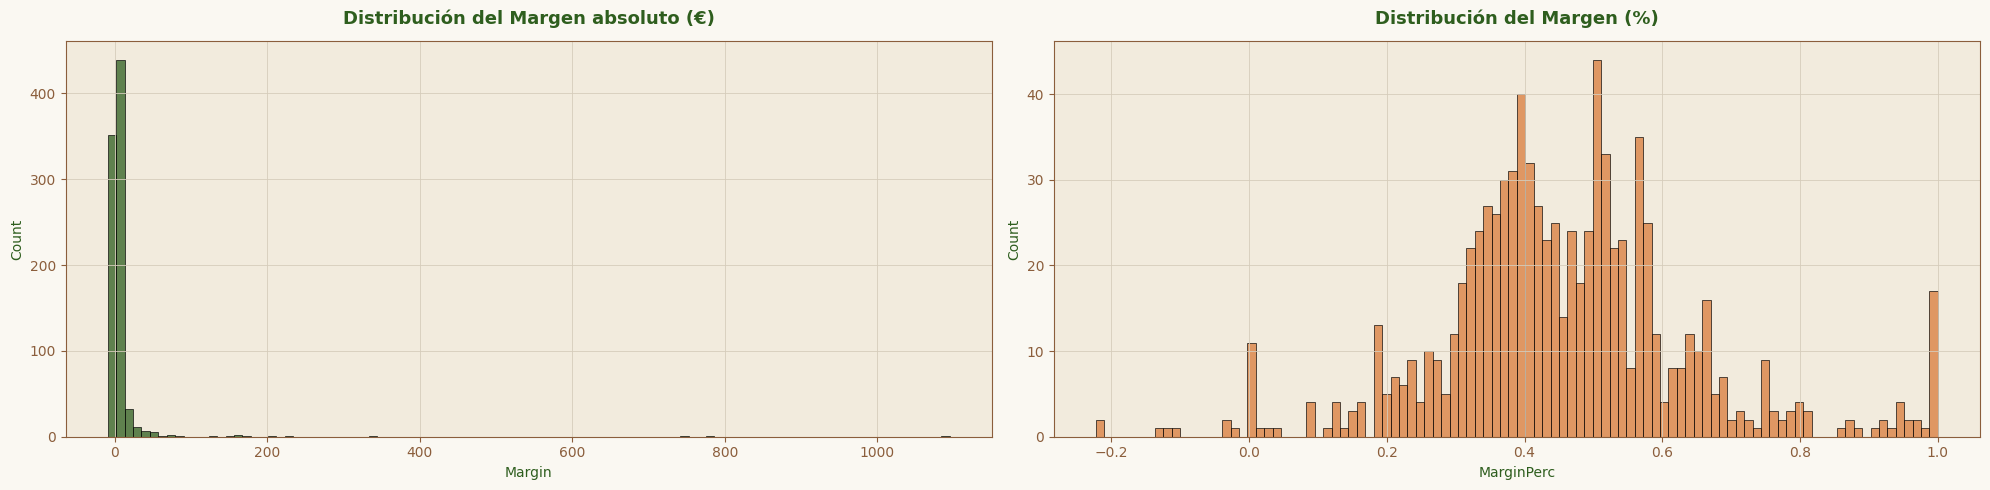

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

sns.histplot(data=df1.Margin, bins=100, ax=ax[0], color=C_PRINCIPAL)
ax[0].set_title("Distribución del Margen absoluto (€)")

sns.histplot(data=df1.MarginPerc, bins=100, ax=ax[1], color=C_NARANJA)
ax[1].set_title("Distribución del Margen (%)")

plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.2 Agrupación y extracción de Top 5 y Bottom 5</h3>

Se agrupa el dataset por producto sumando todas las métricas. Se calculan el margen porcentual real y el precio unitario para comparaciones honestas entre productos.

In [7]:
h1_agrupados = (
    df1.groupby("Name", as_index=False)
    .agg(
        Qty        = ("Qty",        "sum"),
        Value      = ("Value",      "sum"),
        Discount   = ("Discount",   "sum"),
        ValueIncVat= ("ValueIncVAT","sum"),
        ValueExcVat= ("ValueExcVAT","sum"),
        Costo      = ("TotCost",    "sum"),
        Margin     = ("Margin",     "sum"),
        MarginPerc = ("MarginPerc", "sum"),
    )
    .sort_values("Qty", ascending=False)
)

top5 = h1_agrupados.head(5).copy()
bot5 = h1_agrupados.tail(5).copy()

# Métricas derivadas
for df in [top5, bot5]:
    df["MarginPerc_real"] = df.Margin / df.ValueExcVat
    df["precio_unitario"] = df.Value  / df.Qty

margen_total     = h1_agrupados.Margin.sum()
media_marginperc = h1_agrupados.Margin.sum() / h1_agrupados.ValueExcVat.sum()

print("Top 5 por volumen:")
display(top5[["Name","Qty","precio_unitario","Margin","MarginPerc_real"]])

Top 5 por volumen:


,Name,Qty,precio_unitario,Margin,MarginPerc_real
239,Copia A4 B/N,8553,0.15,778.42,0.645419
275,Doble Cara A4 B/N,6100,0.25,1095.10,0.782158
240,Copia A4 Color,2075,0.45,744.81,0.877734
10,2ª Pag,1354,0.12,81.94,0.547581
276,Doble Cara A4 Color,513,0.80,334.95,0.928869


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.3 Visualización del Top 5</h3>

C:\Users\Raquel\AppData\Local\Temp\ipykernel_9148\2733503686.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="Qty",            data=top5, ax=ax[0,0], palette=PALETA_BARS[:5])
C:\Users\Raquel\AppData\Local\Temp\ipykernel_9148\2733503686.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="precio_unitario", data=top5, ax=ax[0,1], palette=PALETA_BARS[:5])
C:\Users\Raquel\AppData\Local\Temp\ipykernel_9148\2733503686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Name", y="Margin",          data=top5, ax=ax[1,

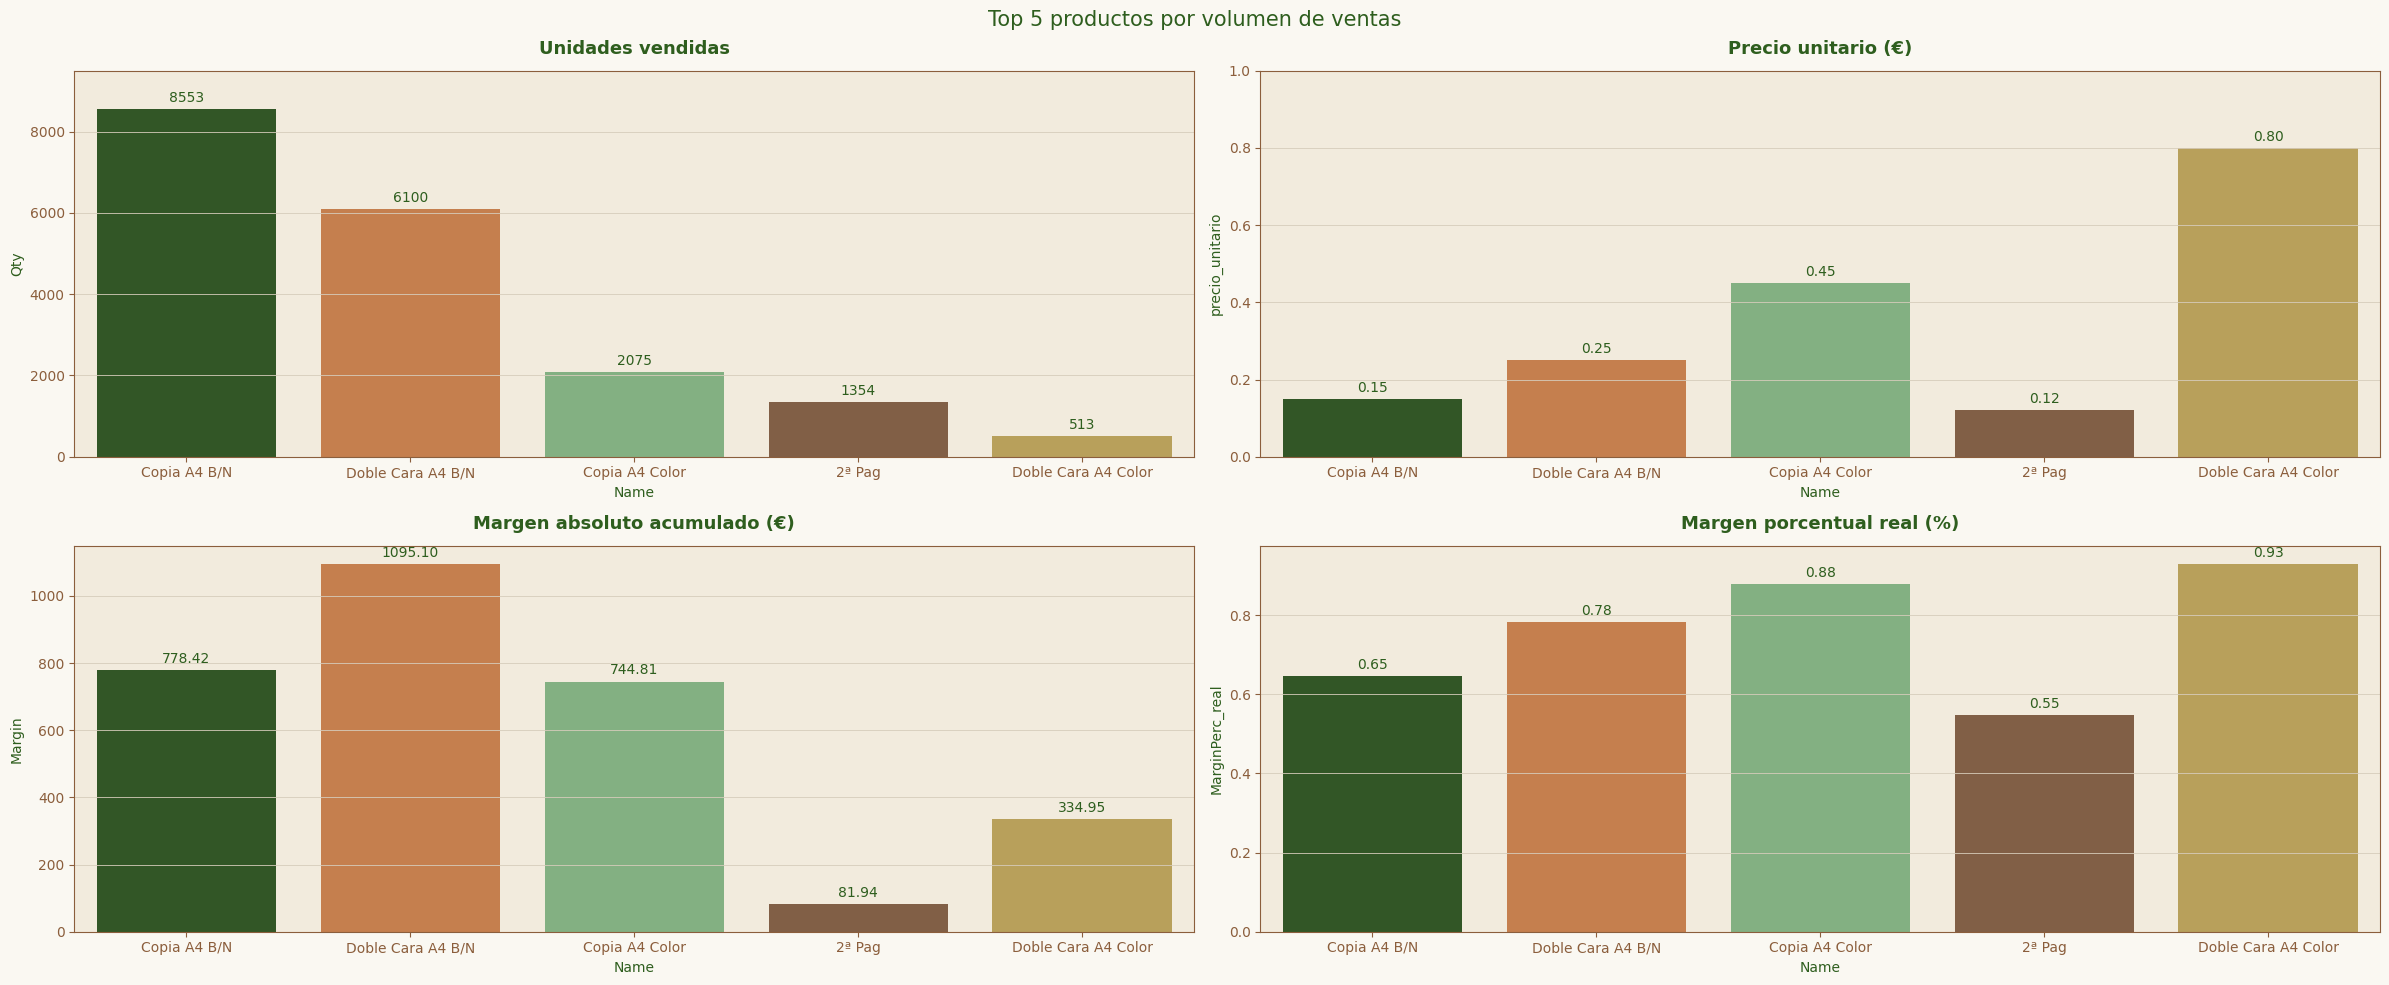

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(24, 10))
fig.suptitle("Top 5 productos por volumen de ventas", fontsize=15)

sns.barplot(x="Name", y="Qty",            data=top5, ax=ax[0,0], palette=PALETA_BARS[:5])
ax[0,0].set_title("Unidades vendidas"); ax[0,0].set_ylim(0, 9500)
for c in ax[0,0].containers: ax[0,0].bar_label(c, fmt="%.0f", padding=3)

sns.barplot(x="Name", y="precio_unitario", data=top5, ax=ax[0,1], palette=PALETA_BARS[:5])
ax[0,1].set_title("Precio unitario (€)"); ax[0,1].set_ylim(0, 1)
for c in ax[0,1].containers: ax[0,1].bar_label(c, fmt="%.2f", padding=3)

sns.barplot(x="Name", y="Margin",          data=top5, ax=ax[1,0], palette=PALETA_BARS[:5])
ax[1,0].set_title("Margen absoluto acumulado (€)")
for c in ax[1,0].containers: ax[1,0].bar_label(c, fmt="%.2f", padding=3)

sns.barplot(x="Name", y="MarginPerc_real", data=top5, ax=ax[1,1], palette=PALETA_BARS[:5])
ax[1,1].set_title("Margen porcentual real (%)")
for c in ax[1,1].containers: ax[1,1].bar_label(c, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.4 Comparativa Top 5 vs Bottom 5</h3>

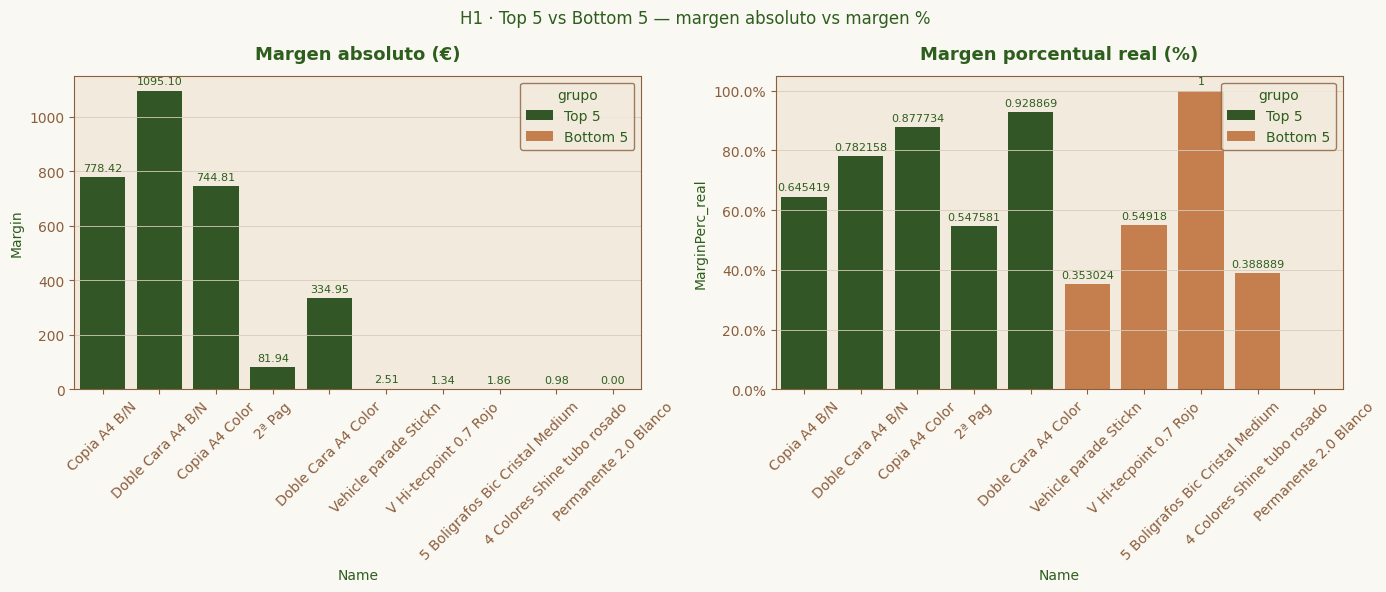

In [9]:
top5["grupo"] = "Top 5"
bot5["grupo"] = "Bottom 5"
comparativa = pd.concat([top5, bot5])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("H1 · Top 5 vs Bottom 5 — margen absoluto vs margen %")

sns.barplot(data=comparativa, x="Name", y="Margin",
            hue="grupo", palette=PALETA_DUO, ax=ax[0])
ax[0].set_title("Margen absoluto (€)")
ax[0].tick_params(axis="x", rotation=45)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.2f", padding=3, fontsize=8)

sns.barplot(data=comparativa, x="Name", y="MarginPerc_real",
            hue="grupo", palette=PALETA_DUO, ax=ax[1])
ax[1].set_title("Margen porcentual real (%)")
ax[1].tick_params(axis="x", rotation=45)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
for c in ax[1].containers: ax[1].bar_label(c, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">3.5 Peso del Top 5 sobre el total del catálogo</h3>

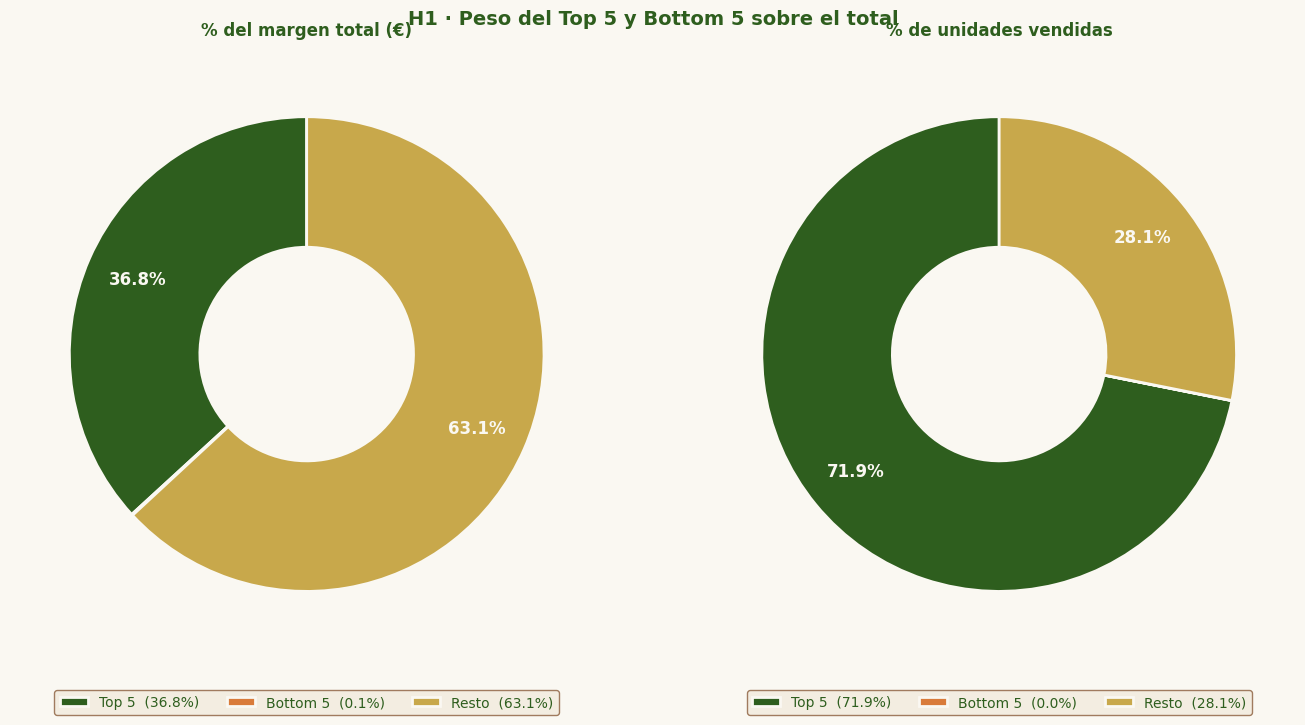

Margen total del negocio:         €8,246.43
Top 5 — margen absoluto:          €3,035.22  (36.8% del total)
Bottom 5 — margen absoluto:       €6.69  (0.1% del total)
Margen % medio del negocio:        56.0%


In [10]:
margen_top5  = top5["Margin"].sum()
margen_bot5  = bot5["Margin"].sum()
margen_resto = margen_total - margen_top5 - margen_bot5

pct_top5  = margen_top5  / margen_total * 100
pct_bot5  = margen_bot5  / margen_total * 100
pct_resto = margen_resto / margen_total * 100

qty_total    = h1_agrupados["Qty"].sum()
pct_qty_top5 = top5["Qty"].sum()  / qty_total * 100
pct_qty_bot5 = bot5["Qty"].sum()  / qty_total * 100
pct_qty_rest = (qty_total - top5["Qty"].sum() - bot5["Qty"].sum()) / qty_total * 100

GRUPOS  = ["Top 5", "Bottom 5", "Resto"]
COLORES = [C_PRINCIPAL, C_NARANJA, C_AMARILLO]  # verde / naranja / dorado

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("H1 · Peso del Top 5 y Bottom 5 sobre el total", fontsize=14, fontweight='bold')

datasets = [
    ([pct_top5, pct_bot5, pct_resto], "% del margen total (€)"),
    ([pct_qty_top5, pct_qty_bot5, pct_qty_rest], "% de unidades vendidas"),
]

for ax_i, (vals, title) in zip(axes, datasets):
    wedges, _, autotexts = ax_i.pie(
        vals,
        colors=COLORES,
        autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor=C_BLANCO, linewidth=2),
        pctdistance=0.78,
    )
    for at, color in zip(autotexts, COLORES):
        at.set_fontsize(12)
        at.set_fontweight("bold")
        at.set_color(C_BLANCO)
    ax_i.set_title(title, fontsize=12, pad=16)
    ax_i.legend(
        wedges, [f"{g}  ({v:.1f}%)" for g, v in zip(GRUPOS, vals)],
        loc="lower center", bbox_to_anchor=(0.5, -0.12),
        frameon=True, fontsize=10, ncol=3
    )

plt.tight_layout()
plt.show()

print(f"Margen total del negocio:         €{margen_total:,.2f}")
print(f"Top 5 — margen absoluto:          €{margen_top5:,.2f}  ({pct_top5:.1f}% del total)")
print(f"Bottom 5 — margen absoluto:       €{margen_bot5:,.2f}  ({pct_bot5:.1f}% del total)")
print(f"Margen % medio del negocio:        {media_marginperc*100:.1f}%")

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusión H1</h3>

**Resultado: Hipótesis rechazada ❌**

Los productos más vendidos por volumen (copistería) no son los que mayor margen absoluto aportan en términos relativos al catálogo. Sin embargo, su gran volumen hace que acumulen el **36.8 % del margen total**, frente al 0.1 % de los 5 menos vendidos.

Clave: el bajo precio unitario (céntimos) limita su margen unitario, pero el volumen los convierte en el motor del negocio.

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">4. Hipótesis 2 — Los productos con margen negativo tienen precios incorrectamente establecidos</h2>

**Hipótesis:** La existencia de productos con margen negativo se debe a que los precios han sido establecidos incorrectamente.

### Contexto del análisis

El objetivo es identificar los productos con margen negativo (Margin < 0), entender la causa raíz y proponer acciones correctoras.

| Bloque | Pregunta | Output |
|---|---|---|
| 1. Caracterización | ¿Cuáles son y cuánto daño hacen? | Tabla + gráficos |
| 2. Causa raíz | ¿Precio, descuento o coste? | Tabla clasificada por causa |
| 3. Recomendaciones | ¿Qué hacer con cada uno? | Tabla de acciones + impacto estimado |

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.1 Filtrado y caracterización de productos con margen negativo</h3>

In [11]:
df2 = articulos.copy()
df2 = df2.drop(columns=["OrderCode", "Brand", "Size", "Description"])

h2_agrupados = (
    df2.groupby("Name", as_index=False)
    .agg(
        Qty         = ("Qty",        "sum"),
        Value       = ("Value",      "sum"),
        Discount    = ("Discount",   "sum"),
        ValueExcVat = ("ValueExcVAT","sum"),
        Costo       = ("TotCost",    "sum"),
        Margin      = ("Margin",     "sum"),
    )
)

h2_agrupados["precio_unitario"] = h2_agrupados.Value    / h2_agrupados.Qty
h2_agrupados["MarginPerc_real"] = h2_agrupados.Margin   / h2_agrupados.ValueExcVat
h2_agrupados["Descuento_pct"]   = h2_agrupados.Discount / h2_agrupados.Value

h2_negativos = h2_agrupados[h2_agrupados.Margin < 0].copy()
h2_negativos["costo_unitario"] = h2_negativos.Costo / h2_negativos.Qty

iva = 0.21
h2_negativos["precio_sinIVA"] = h2_negativos.precio_unitario / (1 + iva)

pct_negativos = round(len(h2_negativos) * 100 / len(h2_agrupados))
print(f"Productos con margen negativo: {len(h2_negativos)} de {len(h2_agrupados)} ({pct_negativos}%)")
print(f"Mayor pérdida: {h2_negativos.Margin.min():.2f} € — {h2_negativos.loc[h2_negativos.Margin.idxmin(), 'Name']}")
display(h2_negativos[["Name","Qty","precio_unitario","costo_unitario","precio_sinIVA","Discount","Margin","MarginPerc_real"]])

Productos con margen negativo: 8 de 856 (1%)
Mayor pérdida: -9.29 € — A4 Doble Cara Color Cartulina


,Name,Qty,precio_unitario,costo_unitario,precio_sinIVA,Discount,Margin,MarginPerc_real
16,5 Boligrafos Bic Cristal,3,0.000,2.75,0.000000,-6.75,-1.50,-0.222222
22,A4 Doble Cara Color Cartulina,49,1.050,1.05,0.867769,9.29,-9.29,-0.220351
56,Bic Cristal 10 azul bolsa,3,3.550,3.04,2.933884,0.00,-0.33,-0.037543
57,Bic Cristal 10 c bolsa,2,3.550,3.04,2.933884,0.00,-0.22,-0.037543
60,Bic Cristal 5 c bolsa,1,2.250,2.06,1.859504,0.00,-0.20,-0.107527
388,Intensity Pack 12,2,4.325,4.45,3.574380,0.00,-0.95,-0.119497
506,Pack 12 aquarela,1,3.650,3.09,3.016529,0.00,-0.07,-0.023179
609,Pizarra Board Master M,1,1.890,0.98,1.561983,0.84,-0.11,-0.126437


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.2 Visualización del impacto</h3>

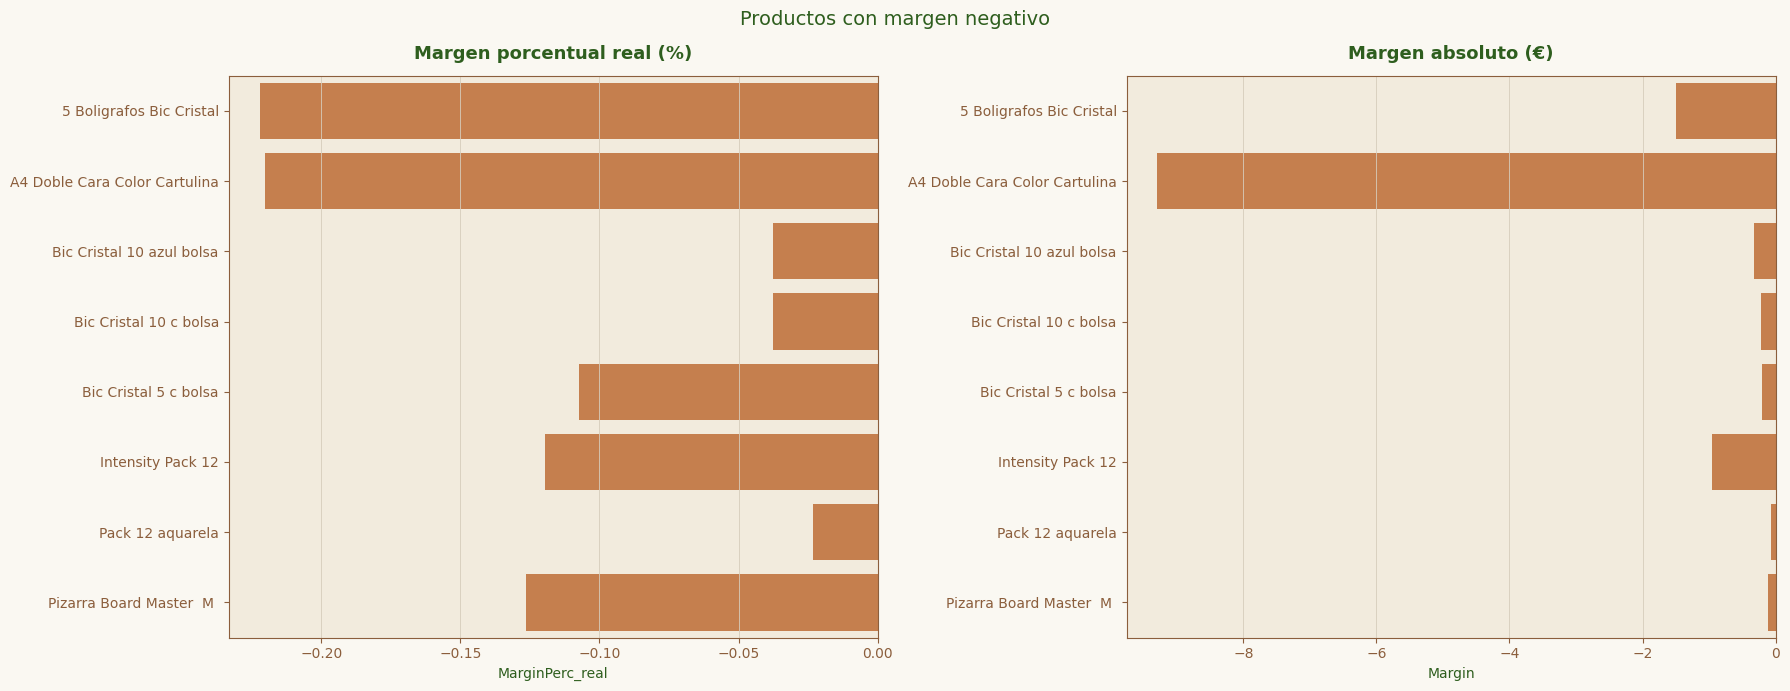

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(y="Name", x="MarginPerc_real", data=h2_negativos, ax=ax[0], color=C_NARANJA)
ax[0].set_title("Margen porcentual real (%)")
ax[0].set_ylabel("")

sns.barplot(y="Name", x="Margin",          data=h2_negativos, ax=ax[1], color=C_NARANJA)
ax[1].set_title("Margen absoluto (€)")
ax[1].set_ylabel("")

plt.suptitle("Productos con margen negativo", fontsize=14)
plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">4.3 Causa raíz</h3>

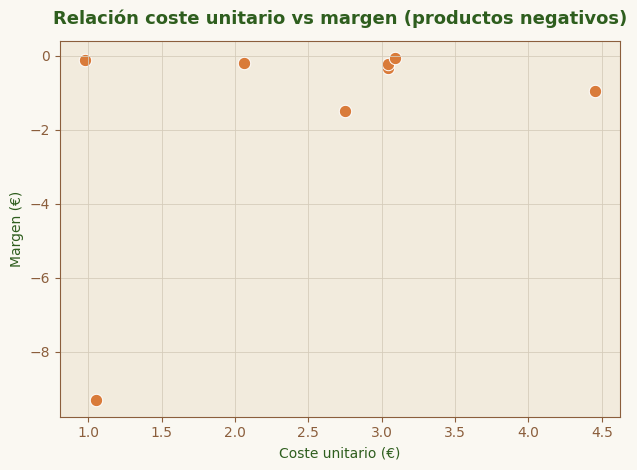

In [13]:
sns.scatterplot(
    x="costo_unitario", y="Margin",
    data=h2_negativos,
    color=C_NARANJA, s=80
)
plt.title("Relación coste unitario vs margen (productos negativos)")
plt.xlabel("Coste unitario (€)")
plt.ylabel("Margen (€)")
plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusión H2</h3>

**Resultado: Hipótesis confirmada ✅**

Solo 8 de 862 artículos (< 1 %) presentan margen negativo. Las causas identificadas son:

| Causa | Productos afectados | Impacto (€) |
|---|---|---|
| Descuento mal imputado | Bolígrafos Bic Cristal | −6,75 € |
| Descuento elimina margen | A4 Doble Cara Color | −9,29 € |
| Precio < Coste en sistema | Resto de productos (6) | Variable |

No existe ningún caso en que el margen negativo sea resultado de una decisión estratégica. Todos son corregibles.

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">5. Hipótesis 3 — El comportamiento de ventas varía por categoría según la hora del día</h2>

**Hipótesis:** El comportamiento de ventas varía significativamente entre categorías de productos en función de la hora del día, evidenciando una correlación entre ambas variables.

**Datasets:** `compras_tpv.csv` · `agrupacion_horas.csv`

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.1 Heatmap — Ventas por categoría y hora</h3>

> **Nota metodológica:** El análisis se realiza en dos versiones: con y sin Copistería. Esta categoría concentra el 78 % del margen total y domina cualquier gráfico, ocultando el comportamiento del resto.

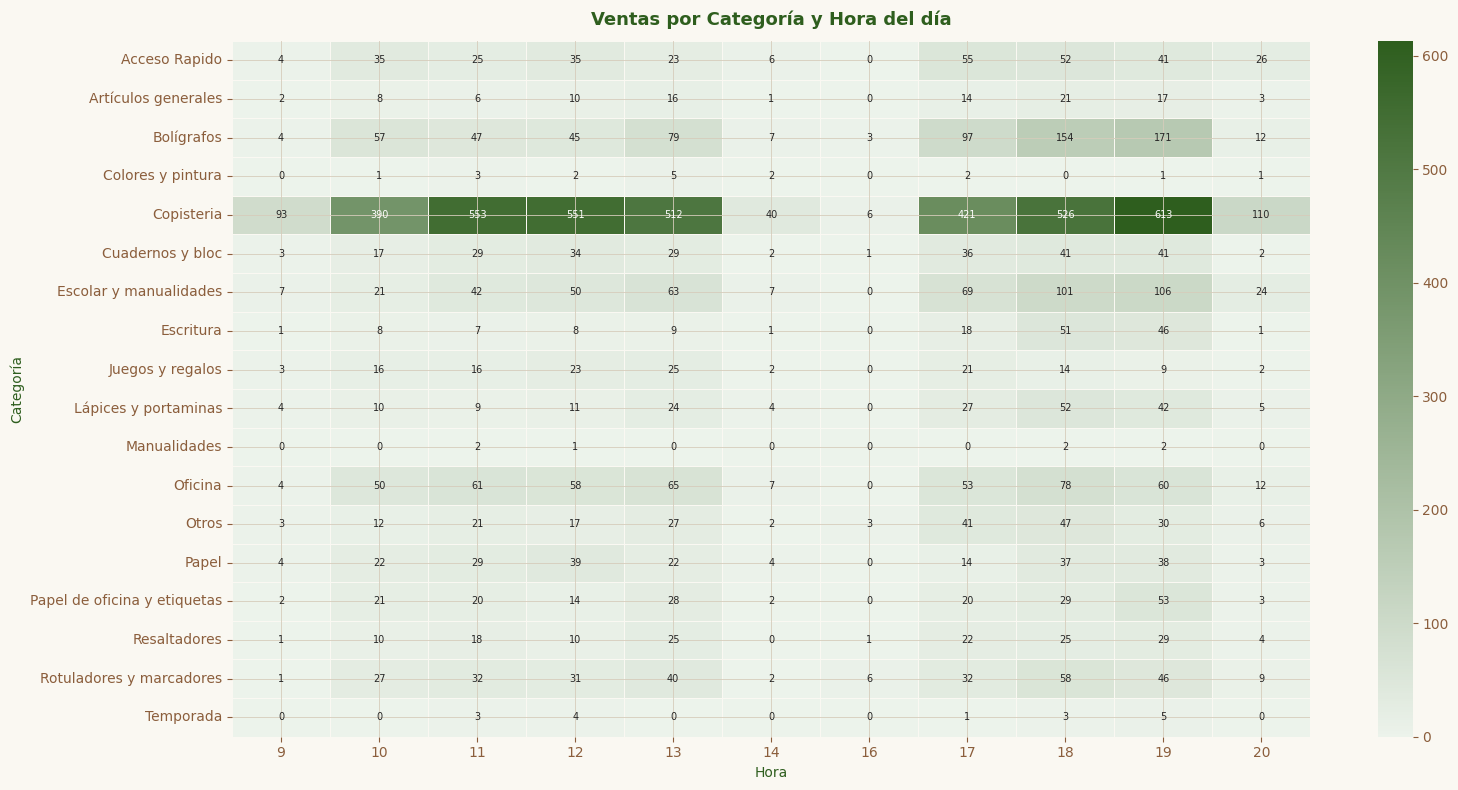

In [14]:
pivot = pd.crosstab(ventas['Categoría'], ventas['Hora'])
cmap_custom = sns.light_palette(C_PRINCIPAL, as_cmap=True, reverse=False)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap=cmap_custom, annot=True, fmt='d',
            linewidths=0.5, linecolor=C_BLANCO, annot_kws={'size': 7})
plt.title("Ventas por Categoría y Hora del día")
plt.xlabel("Hora")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.2 Heatmap — Sin Copistería</h3>

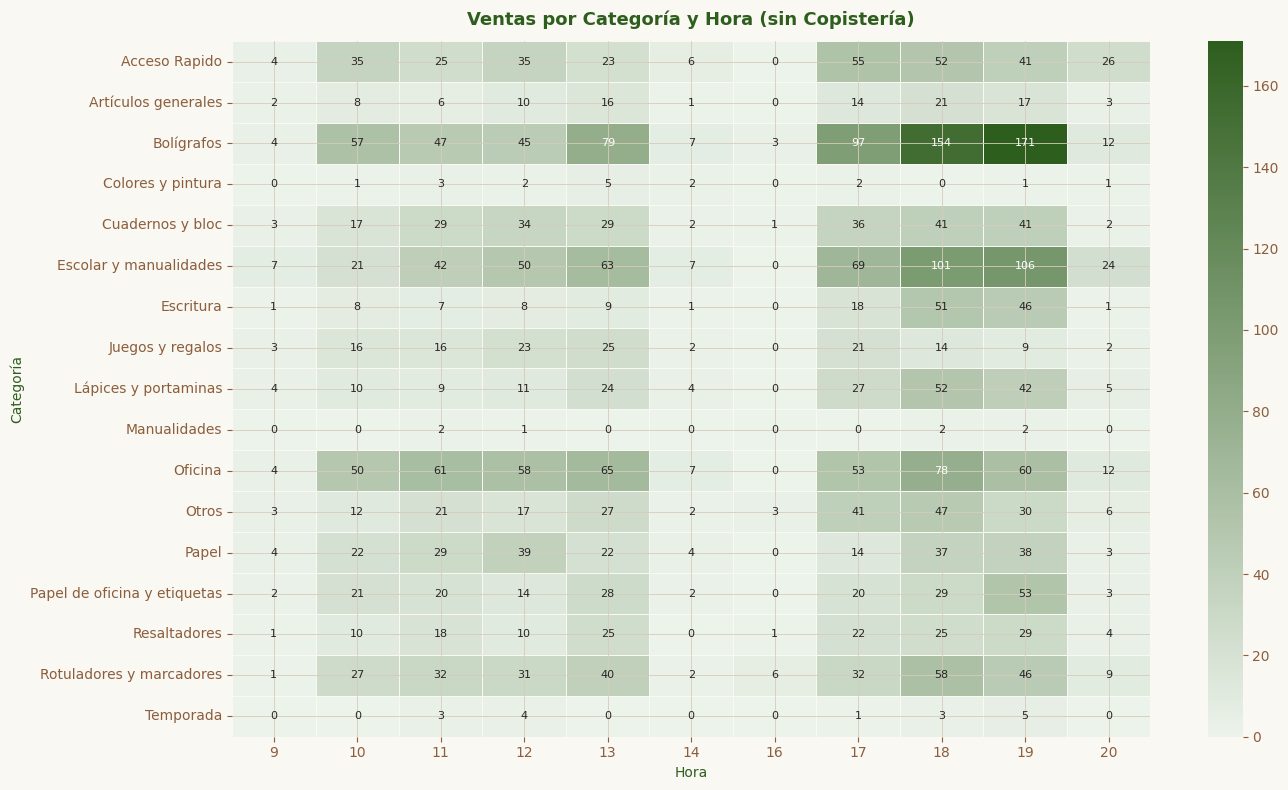

In [15]:
pivot_sin_copia = pivot[~pivot.index.str.contains('Copisteria|Copistería')]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sin_copia, cmap=cmap_custom, annot=True, fmt='d',
            linewidths=0.5, linecolor=C_BLANCO, annot_kws={'size': 8})
plt.title("Ventas por Categoría y Hora (sin Copistería)")
plt.xlabel("Hora")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.3 Test Chi-cuadrado y Cramér's V</h3>

In [16]:
chi2, p_valor, gl, esperados = chi2_contingency(pivot)
print(f"Chi-cuadrado: {chi2:.2f}")
print(f"P-valor:      {p_valor:.6f}")
if p_valor < 0.05:
    print("\n✅ Sí hay relación significativa entre categoría y hora")
else:
    print("\n❌ No hay relación significativa")

n = pivot.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(pivot.shape) - 1)))
print(f"\nCramér's V: {cramers_v:.3f}")
if    cramers_v < 0.1: print("Relación muy débil o inexistente")
elif  cramers_v < 0.3: print("Relación débil")
elif  cramers_v < 0.5: print("Relación moderada")
else:                   print("Relación fuerte")

Chi-cuadrado: 572.87
P-valor:      0.000000

✅ Sí hay relación significativa entre categoría y hora

Cramér's V: 0.087
Relación muy débil o inexistente


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">5.4 Hora pico por categoría</h3>

In [17]:
hora_pico = (
    ventas.groupby("Categoría")["Hora"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"Hora": "Hora pico"})
)
display(hora_pico)

,Categoría,Hora pico
0,Acceso Rapido,17
1,Artículos generales,18
2,Bolígrafos,19
3,Colores y pintura,13
4,Copisteria,19
5,Cuadernos y bloc,19
6,Escolar y manualidades,19
7,Escritura,18
8,Juegos y regalos,13
9,Lápices y portaminas,18


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusión H3</h3>

**Resultado: Hipótesis confirmada ✅ (con matices)**

- La relación estadística existe (p-valor significativo) pero es muy débil (Cramér's V ≈ 0.087).
- Todas las categorías siguen el mismo **patrón bimodal**: mañana (10-13h) y tarde (17-19h).
- **Bolígrafos y Escolar** tienen pico por la tarde (salida de colegios). **Oficina** es más de mañana.
- La franja de 14-16h muestra actividad mínima: posible oportunidad de horario extendido.
- No tiene sentido diseñar promociones por categoría según hora; sí tiene sentido reforzar personal en los picos.

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">6. Hipótesis 4 — Las ventas de Glovo representan una proporción significativa de las ventas globales</h2>

**Hipótesis:** Las ventas realizadas a través de Glovo representan una proporción significativa de las ventas globales de la papelería, generando un impacto en sus ingresos totales.

**Datasets:** `ventas_glovo.csv` · `compras_tpv.csv`

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">6.1 Calidad del dataset Glovo</h3>

In [18]:
print("Nulos:")
print(glovo.isnull().sum())
print(f"\nDuplicados: {glovo.duplicated().sum()}")
print(f"Shape: {glovo.shape}")
display(glovo.describe())

Nulos:
Name             0
Description      1
Category         0
Price            0
Qty              0
SalesIncVAT      0
Discount         0
NetIncVAT        0
NetExcVAT        0
TotalCost        0
Margin           0
MarginPercent    0
dtype: int64

Duplicados: 0
Shape: (59, 12)


,Price,Qty,SalesIncVAT,Discount,NetIncVAT,NetExcVAT,TotalCost,Margin,MarginPercent
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,4.303559,2.372881,11.431356,-0.715254,12.146610,10.200000,5.048983,5.151017,0.523744
std,3.208444,2.041790,13.515844,2.247340,12.990504,10.676336,5.774381,5.660859,0.202825
min,0.000000,1.000000,0.000000,-12.600000,1.000000,0.830000,0.000000,-1.500000,-0.222200
25%,2.645000,1.000000,3.095000,0.000000,3.550000,3.010000,1.340000,1.520000,0.460650
50%,3.450000,1.000000,5.850000,0.000000,5.990000,5.280000,2.490000,2.600000,0.519000
75%,5.990000,3.000000,16.165000,0.000000,16.165000,13.645000,6.565000,6.475000,0.632100
max,15.450000,9.000000,63.350000,1.450000,63.350000,52.360000,27.230000,25.130000,1.000000


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">6.2 Comparativa Tienda vs Glovo</h3>

In [19]:
# Separar canal tienda y canal Glovo desde compras_tpv
col_canal = "Comida para consumir en el Lugar o para Llevar"
tienda_df = ventas[ventas[col_canal] == "Eat in"]
glovo_tpv = ventas[ventas[col_canal] == "Take Out"]

resumen = pd.DataFrame({
    "Métrica": ["Ventas totales (€)", "Margen total (€)", "Margen medio (%)",
                "Ticket medio (€)", "Transacciones"],
    "Tienda (Eat in)": [
        f"{tienda_df['Ventas NETAS'].sum():,.2f} €",
        f"{tienda_df['Margen'].sum():,.2f} €",
        f"{tienda_df['Margen'].sum()/tienda_df['Ventas NETAS'].sum()*100:.1f} %",
        f"{tienda_df['Ventas NETAS'].mean():,.2f} €",
        f"{len(tienda_df):,}"
    ],
    "Glovo (Take Out)": [
        f"{glovo['SalesIncVAT'].sum():,.2f} €",
        f"{glovo['Margin'].sum():,.2f} €",
        f"{glovo['Margin'].sum()/glovo['SalesIncVAT'].sum()*100:.1f} %",
        f"{glovo['SalesIncVAT'].mean():,.2f} €",
        f"{len(glovo_tpv):,}"
    ]
})
display(resumen)

,Métrica,Tienda (Eat in),Glovo (Take Out)
0,Ventas totales (€),"14,134.76 €",674.45 €
1,Margen total (€),"7,942.47 €",303.91 €
2,Margen medio (%),56.2 %,45.1 %
3,Ticket medio (€),1.89 €,11.43 €
4,Transacciones,"7,486",129


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">6.3 Distribución de variables numéricas en Glovo</h3>

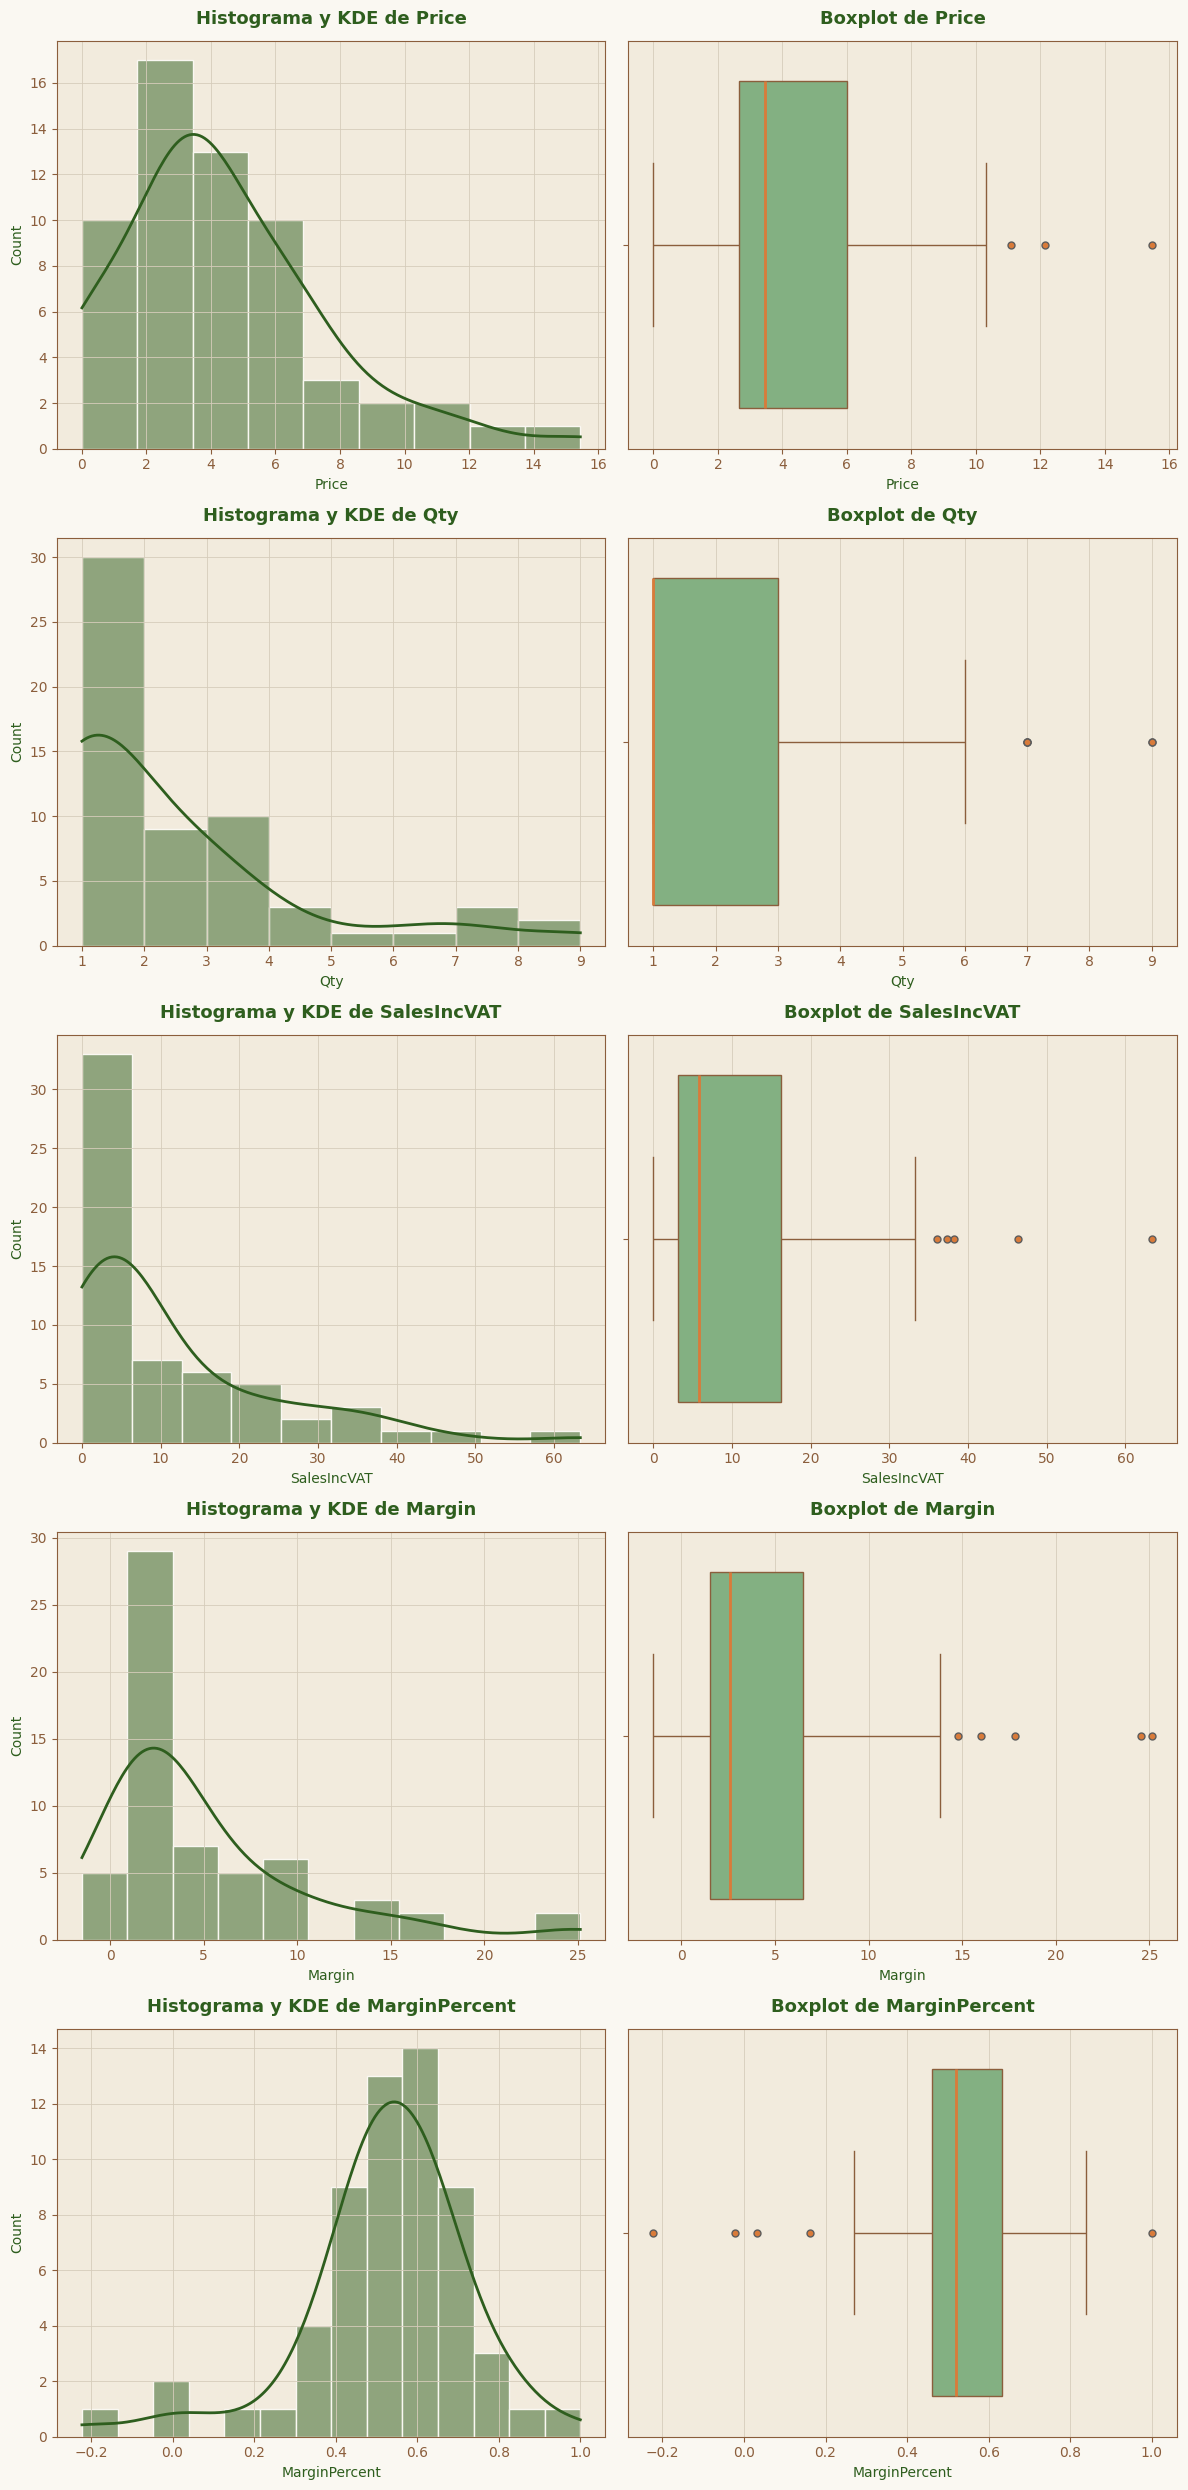

In [20]:
plot_combined_graphs(glovo, ['Price', 'Qty', 'SalesIncVAT', 'Margin', 'MarginPercent'])

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">6.4 Correlación Precio vs Margen en Glovo</h3>

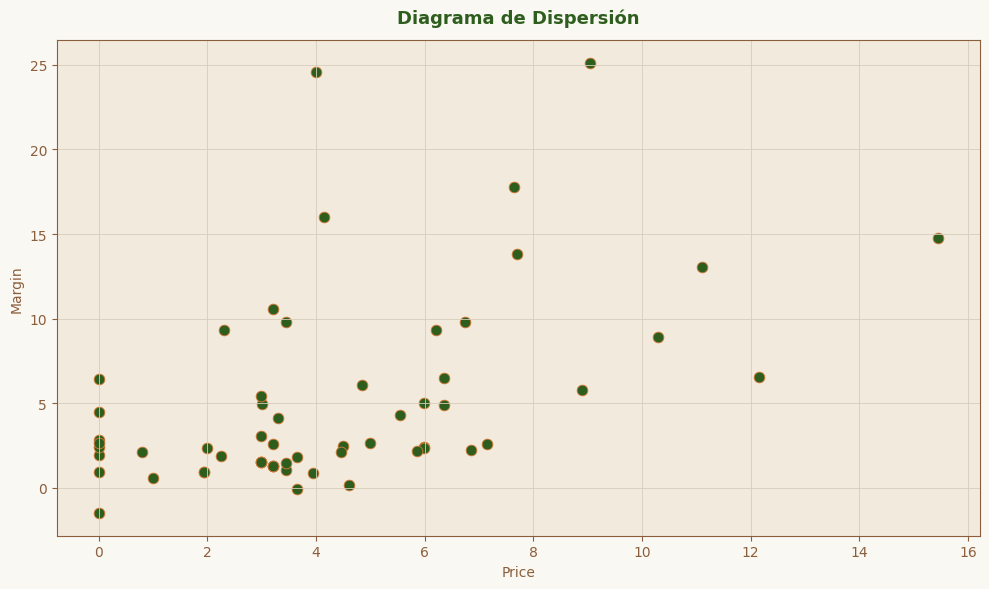

In [21]:
grafico_dispersion_con_correlacion(glovo, "Price", "Margin")

<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">6.5 Análisis por categoría en Glovo</h3>

In [22]:
glovo_cat = (
    glovo.groupby("Category", as_index=False)
    .agg(
        Productos  = ("Name",        "count"),
        Uds        = ("Qty",         "sum"),
        Ventas_EUR = ("SalesIncVAT", "sum"),
        Margen_EUR = ("Margin",      "sum"),
    )
)
glovo_cat["Mg_pct"] = glovo_cat.Margen_EUR / glovo_cat.Ventas_EUR * 100
display(glovo_cat.sort_values("Ventas_EUR", ascending=False))

,Category,Productos,Uds,Ventas_EUR,Margen_EUR,Mg_pct
12,Manualidades,7,31,186.10,74.91,40.252552
13,Navigator,3,14,127.45,52.02,40.816006
6,Colores y pintura,6,13,102.30,35.54,34.740958
15,Pilot,12,22,70.97,31.82,44.835846
4,Blocs,2,15,49.80,33.87,68.012048
3,BIC,7,10,35.34,10.43,29.513299
1,Alpino,3,5,29.20,14.34,49.109589
8,Cuadernos y bloc,1,3,17.97,2.40,13.355593
11,Faber-Castell,4,7,13.55,11.39,84.059041
9,Dibujo escolar y técnico,3,3,12.98,7.97,61.402157


<h3 style="color:#8B7355; border-left: 4px solid #8FAD6D; padding-left: 8px;">Conclusión H4</h3>

**Resultado: Hipótesis rechazada ❌**

Glovo representa solo el **1,7 % de las transacciones** totales (129 pedidos vs 7.486 en tienda). Su impacto en ingresos es marginal (≈ 601 € vs 14.135 € en tienda).

Sin embargo, presenta un **ticket medio superior** (4,67 € vs 1,89 €) y un margen del 50,5 %. Las categorías más eficientes son **Blocs** (82 % de margen) y **Navigator** (50 % con solo 3 productos).

Oportunidad: optimizar el catálogo Glovo priorizando productos con precio > 4 € para maximizar el margen por pedido.

<h2 style="color:#3E5F36; border-bottom: 2px solid #8B7355; padding-bottom: 4px;">7. Conclusiones generales</h2>

| Hipótesis | Resultado | Hallazgo clave |
|---|---|---|
| H1 — Top 5 volumen = Top 5 margen | ❌ Rechazada | Los 5 más vendidos aportan el 36,8 % del margen total, pero no son los más rentables por unidad |
| H2 — Margen negativo por precio incorrecto | ✅ Confirmada | 8 productos (< 1 %) con margen negativo, todos por errores de registro corregibles |
| H3 — Ventas varían por categoría y hora | ✅ Confirmada (débil) | Patrón bimodal universal; diferencias por categoría son estadísticamente significativas pero débiles |
| H4 — Glovo representa proporción significativa | ❌ Rechazada | Solo 1,7 % de transacciones, aunque con ticket medio superior y buenos márgenes |

### Acciones recomendadas

**Correcciones inmediatas**
- Corregir precio en sistema de los 8 productos con margen negativo.
- Revisar descuento de Bolígrafos Bic Cristal y los 2 productos negativos en Glovo.

**Optimización del catálogo Glovo**
- Reducir catálogo de Pilot de 12 a 5-6 referencias más vendidas.
- Priorizar productos con precio > 4 € y ampliar presencia de Blocs y Manualidades.

**Estrategia operativa**
- Reforzar personal en franjas 10-13h y 17-19h.
- Evaluar apertura en franja 14-16h, especialmente para Oficina.